In [82]:
import pandas as pd
from utils import Utils as utils
from keras.datasets import mnist
import numpy as np  
import importlib
from dataclasses import dataclass
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
@dataclass
class MNIST:
    data_train: np.array
    labels_train: np.array
    data_test: np.array
    labels_test: np.array
    
    @classmethod
    def generate(self, n_training_samples):
        (data_train, labels_train), (data_test, labels_test) = mnist.load_data()
        data_train = data_train[:n_training_samples]
        labels_train = labels_train[:n_training_samples]
        return MNIST(data_train, labels_train, data_test, labels_test)
    def plot_example(self):
        fig = plot_digits_plotly(self, "MNIST Digits")
        fig.show()
    def reshape(self):
        self.data_train = self.data_train.reshape(self.data_train.shape[0], -1)
        self.data_test = self.data_test.reshape(self.data_test.shape[0], -1)

In [27]:
def plot_digits_plotly(mnist_data: MNIST, title: str):

    fig = make_subplots(2, 5, subplot_titles=[f"Digit {i}" for i in range(10)])
    current_digit = 0

    for i in range(10):
        # Get the first image of the current digit
        image_index = np.where(mnist_data.labels_train == current_digit)[0][0]
        image = mnist_data.data_train[image_index]
        image = np.flipud(image)

        # Add image to the subplot using Heatmap for grayscale images
        fig.add_trace(
            go.Heatmap(
                z=image,
                colorscale="Greys_r",
                showscale=False,
            ),
            row=(i // 5) + 1,
            col=(i % 5) + 1,
        )
        current_digit += 1

    # Update layout of the figure
    fig.update_layout(
        height=600, width=1000, title_text="Digits Dataset", template="plotly_dark",
    )
    fig.update_xaxes(showticklabels=False)
    fig.update_yaxes(showticklabels=False)
    # Show the figure
    return fig

In [29]:
ALPHAS = [0.3, 0.6, 0.8, 1, 2, 4, 8, 16, 32, 64, 100, 128]
print(len(ALPHAS))

12


In [31]:
mnist_data = MNIST.generate(30000)
mnist_data.plot_example()

In [33]:
raw_data = mnist_data.data_train
reshaped_data = raw_data.reshape(raw_data.shape[0], -1)
labels = mnist_data.labels_train


tsne_embeddings = utils.compute_tsne_embedding(raw_data = reshaped_data, alphas = ALPHAS, labels = mnist_data.labels_train, dataset_name="MNIST (30000)", compute_metrics = True, save_results=True)

Computing the shared affinities...
Computing the PCA initialization...
Computing t-SNE embedding for alpha=0.3...
Computing t-SNE embedding for alpha=0.6...
Computing t-SNE embedding for alpha=0.8...
Computing t-SNE embedding for alpha=1...
Computing t-SNE embedding for alpha=2...
Computing t-SNE embedding for alpha=4...
Computing t-SNE embedding for alpha=8...
Computing t-SNE embedding for alpha=16...
Computing t-SNE embedding for alpha=32...
Computing t-SNE embedding for alpha=64...
Computing t-SNE embedding for alpha=100...
Computing t-SNE embedding for alpha=128...
Saving results to a .pkl file...


In [44]:
digit_1 = np.where(mnist_data.labels_train == 1)[0]
print(digit_1)
digit_1 = reshaped_data[digit_1]
print(digit_1.shape)


[    3     6     8 ... 29976 29986 29999]
(3423, 784)


In [45]:
digits_classes = np.unique(labels)
print(digits_classes)
tsne_per_digits_class = []
for i in range(len(digits_classes)):
    print('processing class:', i)
    current_class_indices = np.where(labels == i)[0]
    digits_of_current_class = reshaped_data[current_class_indices]
    tsne_of_current_class = utils.compute_tsne_embedding(raw_data = digits_of_current_class, alphas = ALPHAS, labels = mnist_data.labels_train[current_class_indices], dataset_name=f"MNIST Digit {i}", compute_metrics = True, save_results=True)
    tsne_per_digits_class.append(tsne_of_current_class)

[0 1 2 3 4 5 6 7 8 9]
processing class: 0
Computing the shared affinities...
Computing the PCA initialization...
Computing t-SNE embedding for alpha=0.3...
Computing t-SNE embedding for alpha=0.6...
Computing t-SNE embedding for alpha=0.8...
Computing t-SNE embedding for alpha=1...
Computing t-SNE embedding for alpha=2...
Computing t-SNE embedding for alpha=4...
Computing t-SNE embedding for alpha=8...
Computing t-SNE embedding for alpha=16...
Computing t-SNE embedding for alpha=32...
Computing t-SNE embedding for alpha=64...
Computing t-SNE embedding for alpha=100...
Computing t-SNE embedding for alpha=128...
Saving results to a .pkl file...
processing class: 1
Computing the shared affinities...
Computing the PCA initialization...
Computing t-SNE embedding for alpha=0.3...
Computing t-SNE embedding for alpha=0.6...
Computing t-SNE embedding for alpha=0.8...
Computing t-SNE embedding for alpha=1...
Computing t-SNE embedding for alpha=2...
Computing t-SNE embedding for alpha=4...
Comput

In [70]:
@dataclass
class DataSetTSNE:
    dataset_name: str
    tsne_results: List[utils.TSNEResult]
    alphas: List[float] = None
    KLs: List[float] = None
    min_KL: float = 0
    optimal_alpha_KL: float = 0
    max_kNN_recall: float = 0
    kNNs: List[float] = None
    optimal_alpha_kNN: float = 0
    def __post_init__(self):
        self.alphas = [alpha for alpha in self.alphas]
        self.KLs = [result.KL for result in self.tsne_results]
        self.min_KL = min([result.KL for result in self.tsne_results])
        self.optimal_alpha_KL = self.alphas[np.argmin([result.KL for result in self.tsne_results])]
        self.kNNs = [result.kNN_recall for result in self.tsne_results]
        self.max_kNN_recall = max([result.kNN_recall for result in self.tsne_results])
        self.optimal_alpha_kNN = self.alphas[np.argmax([result.kNN_recall for result in self.tsne_results])]
        

In [71]:
mnist_all_digits_tsne = DataSetTSNE("MNIST (30000)", tsne_embeddings, ALPHAS)
mnist_digit_1 = DataSetTSNE("MNIST Digit 1", tsne_per_digits_class[1], ALPHAS)
mnist_digit_2 = DataSetTSNE("MNIST Digit 2", tsne_per_digits_class[2], ALPHAS)
mnist_digit_3 = DataSetTSNE("MNIST Digit 3", tsne_per_digits_class[3], ALPHAS)
mnist_digit_4 = DataSetTSNE("MNIST Digit 4", tsne_per_digits_class[4], ALPHAS)
mnist_digit_5 = DataSetTSNE("MNIST Digit 5", tsne_per_digits_class[5], ALPHAS)
mnist_digit_6 = DataSetTSNE("MNIST Digit 6", tsne_per_digits_class[6], ALPHAS)
mnist_digit_7 = DataSetTSNE("MNIST Digit 7", tsne_per_digits_class[7], ALPHAS)
mnist_digit_8 = DataSetTSNE("MNIST Digit 8", tsne_per_digits_class[8], ALPHAS)
mnist_digit_9 = DataSetTSNE("MNIST Digit 9", tsne_per_digits_class[9], ALPHAS)
mnist_digit_0 = DataSetTSNE("MNIST Digit 0", tsne_per_digits_class[0], ALPHAS)



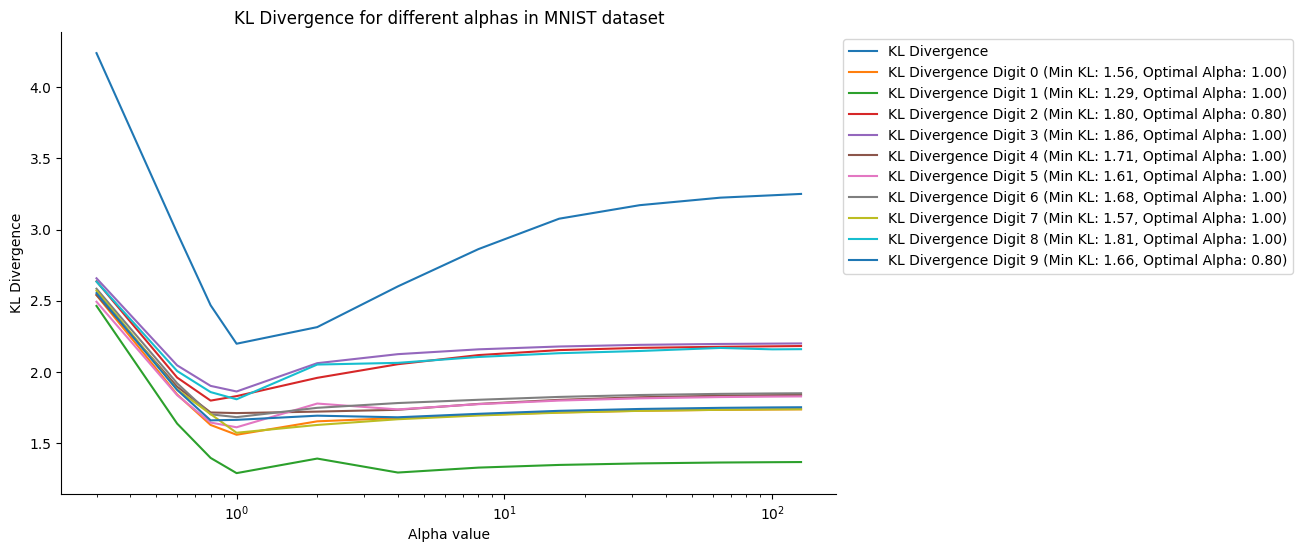

In [85]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(mnist_all_digits_tsne.alphas, mnist_all_digits_tsne.KLs, label="KL Divergence")
ax.plot(mnist_digit_0.alphas, mnist_digit_0.KLs, label=f"KL Divergence Digit 0 (Min KL: {mnist_digit_0.min_KL:.2f}, Optimal Alpha: {mnist_digit_0.optimal_alpha_KL:.2f})")
ax.plot(mnist_digit_1.alphas, mnist_digit_1.KLs, label=f"KL Divergence Digit 1 (Min KL: {mnist_digit_1.min_KL:.2f}, Optimal Alpha: {mnist_digit_1.optimal_alpha_KL:.2f})")
ax.plot(mnist_digit_2.alphas, mnist_digit_2.KLs, label=f"KL Divergence Digit 2 (Min KL: {mnist_digit_2.min_KL:.2f}, Optimal Alpha: {mnist_digit_2.optimal_alpha_KL:.2f})")
ax.plot(mnist_digit_3.alphas, mnist_digit_3.KLs, label=f"KL Divergence Digit 3 (Min KL: {mnist_digit_3.min_KL:.2f}, Optimal Alpha: {mnist_digit_3.optimal_alpha_KL:.2f})")
ax.plot(mnist_digit_4.alphas, mnist_digit_4.KLs, label=f"KL Divergence Digit 4 (Min KL: {mnist_digit_4.min_KL:.2f}, Optimal Alpha: {mnist_digit_4.optimal_alpha_KL:.2f})")
ax.plot(mnist_digit_5.alphas, mnist_digit_5.KLs, label=f"KL Divergence Digit 5 (Min KL: {mnist_digit_5.min_KL:.2f}, Optimal Alpha: {mnist_digit_5.optimal_alpha_KL:.2f})")
ax.plot(mnist_digit_6.alphas, mnist_digit_6.KLs, label=f"KL Divergence Digit 6 (Min KL: {mnist_digit_6.min_KL:.2f}, Optimal Alpha: {mnist_digit_6.optimal_alpha_KL:.2f})")
ax.plot(mnist_digit_7.alphas, mnist_digit_7.KLs, label=f"KL Divergence Digit 7 (Min KL: {mnist_digit_7.min_KL:.2f}, Optimal Alpha: {mnist_digit_7.optimal_alpha_KL:.2f})")
ax.plot(mnist_digit_8.alphas, mnist_digit_8.KLs, label=f"KL Divergence Digit 8 (Min KL: {mnist_digit_8.min_KL:.2f}, Optimal Alpha: {mnist_digit_8.optimal_alpha_KL:.2f})")
ax.plot(mnist_digit_9.alphas, mnist_digit_9.KLs, label=f"KL Divergence Digit 9 (Min KL: {mnist_digit_9.min_KL:.2f}, Optimal Alpha: {mnist_digit_9.optimal_alpha_KL:.2f})")
ax.set_xscale("log")
sns.despine()
plt.tight_layout
ax.set_xlabel("Alpha value")
ax.set_ylabel("KL Divergence")
ax.set_title("KL Divergence for different alphas in MNIST dataset")
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')


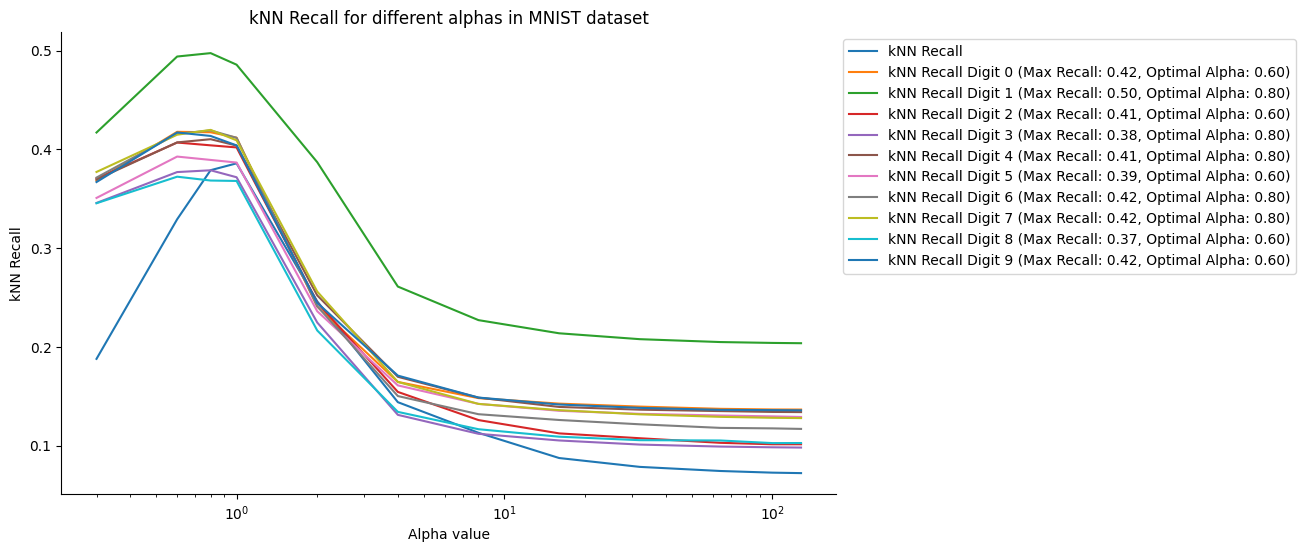

In [86]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(mnist_all_digits_tsne.alphas, mnist_all_digits_tsne.kNNs, label="kNN Recall")
ax.plot(mnist_digit_0.alphas, mnist_digit_0.kNNs, label=f"kNN Recall Digit 0 (Max Recall: {mnist_digit_0.max_kNN_recall:.2f}, Optimal Alpha: {mnist_digit_0.optimal_alpha_kNN:.2f})")
ax.plot(mnist_digit_1.alphas, mnist_digit_1.kNNs, label=f"kNN Recall Digit 1 (Max Recall: {mnist_digit_1.max_kNN_recall:.2f}, Optimal Alpha: {mnist_digit_1.optimal_alpha_kNN:.2f})")
ax.plot(mnist_digit_2.alphas, mnist_digit_2.kNNs, label=f"kNN Recall Digit 2 (Max Recall: {mnist_digit_2.max_kNN_recall:.2f}, Optimal Alpha: {mnist_digit_2.optimal_alpha_kNN:.2f})")
ax.plot(mnist_digit_3.alphas, mnist_digit_3.kNNs, label=f"kNN Recall Digit 3 (Max Recall: {mnist_digit_3.max_kNN_recall:.2f}, Optimal Alpha: {mnist_digit_3.optimal_alpha_kNN:.2f})")
ax.plot(mnist_digit_4.alphas, mnist_digit_4.kNNs, label=f"kNN Recall Digit 4 (Max Recall: {mnist_digit_4.max_kNN_recall:.2f}, Optimal Alpha: {mnist_digit_4.optimal_alpha_kNN:.2f})")
ax.plot(mnist_digit_5.alphas, mnist_digit_5.kNNs, label=f"kNN Recall Digit 5 (Max Recall: {mnist_digit_5.max_kNN_recall:.2f}, Optimal Alpha: {mnist_digit_5.optimal_alpha_kNN:.2f})")
ax.plot(mnist_digit_6.alphas, mnist_digit_6.kNNs, label=f"kNN Recall Digit 6 (Max Recall: {mnist_digit_6.max_kNN_recall:.2f}, Optimal Alpha: {mnist_digit_6.optimal_alpha_kNN:.2f})")
ax.plot(mnist_digit_7.alphas, mnist_digit_7.kNNs, label=f"kNN Recall Digit 7 (Max Recall: {mnist_digit_7.max_kNN_recall:.2f}, Optimal Alpha: {mnist_digit_7.optimal_alpha_kNN:.2f})")
ax.plot(mnist_digit_8.alphas, mnist_digit_8.kNNs, label=f"kNN Recall Digit 8 (Max Recall: {mnist_digit_8.max_kNN_recall:.2f}, Optimal Alpha: {mnist_digit_8.optimal_alpha_kNN:.2f})")
ax.plot(mnist_digit_9.alphas, mnist_digit_9.kNNs, label=f"kNN Recall Digit 9 (Max Recall: {mnist_digit_9.max_kNN_recall:.2f}, Optimal Alpha: {mnist_digit_9.optimal_alpha_kNN:.2f})")
ax.set_xscale("log")
sns.despine()
plt.tight_layout
ax.set_xlabel("Alpha value")
ax.set_ylabel("kNN Recall")
ax.set_title("kNN Recall for different alphas in MNIST dataset")
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
mnist_tsne = pd.read_csv('tsne_results_mnist_all_datapoints_all_alphas.csv')


In [4]:
ALPHAS = [0.3, 0.6, 0.8, 1, 2, 4, 8, 16, 32, 64, 100]

In [ ]:
# number of columns
n_cols = mnist_tsne.shape[1]

values_col_1 = mnist_tsne.iloc[:, 0].values
print(values_col_1.shape)

In [6]:
tsne_results = []
for i in range(1, n_cols-2, 2):
    tsne_result_alpha_i_x = mnist_tsne.iloc[:, i].values
    tsne_result_alpha_i_y = mnist_tsne.iloc[:, i+1].values
    tsne_result_alpha_i = np.column_stack((tsne_result_alpha_i_x, tsne_result_alpha_i_y))
    tsne_results.append(tsne_result_alpha_i)

In [ ]:
print(len(ALPHAS))